In [1]:
import os

folders = [
    "salary_prediction",
    "salary_prediction/data/raw",
    "salary_prediction/data/processed",
    "salary_prediction/data/features",
    "salary_prediction/reports",
    "salary_prediction/models",
    "salary_prediction/src",
    "salary_prediction/mlruns"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created successfully.")

Project structure created successfully.


In [2]:
import shutil

source_file = "Salary Data.xlsx"
destination_file = "salary_prediction/data/raw/Salary Data.xlsx"

shutil.copy2(source_file, destination_file)

print("Salary data copied successfully.")

Salary data copied successfully.


In [3]:
import pandas as pd

data_path = "salary_prediction/data/raw/Salary Data.xlsx"

df = pd.read_excel(data_path)

print("Data loaded successfully.")
print("Shape:", df.shape)

df.head()

Data loaded successfully.
Shape: (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [5]:
print("Missing Values")
print("=" * 50)

print(df.isnull().sum())

Missing Values
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [6]:
print("Number of duplicate rows:")

print(df.duplicated().sum())

Number of duplicate rows:
50


In [7]:
df.describe(include="all")

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,373.000000,373,373,373,373.000000,373.000000
unique,NaN,2,3,174,NaN,NaN
top,NaN,Male,Bachelor's,Director of Marketing,NaN,NaN
freq,NaN,194,224,12,NaN,NaN
mean,37.431635,NaN,NaN,NaN,10.030831,100577.345845
std,7.069073,NaN,NaN,NaN,6.557007,48240.013482
min,23.000000,NaN,NaN,NaN,0.000000,350.000000
25%,31.000000,NaN,NaN,NaN,4.000000,55000.000000
50%,36.000000,NaN,NaN,NaN,9.000000,95000.000000
75%,44.000000,NaN,NaN,NaN,15.000000,140000.000000


In [8]:
required_columns = [
    "Age",
    "Gender",
    "Education Level",
    "Job Title",
    "Years of Experience",
    "Salary"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if len(missing_columns) == 0:
    print("Schema validation PASSED")
else:
    print("Missing columns:", missing_columns)

Schema validation PASSED


In [9]:
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Convert numerical columns
clean_df["Age"] = pd.to_numeric(
    clean_df["Age"],
    errors="coerce"
)

clean_df["Years of Experience"] = pd.to_numeric(
    clean_df["Years of Experience"],
    errors="coerce"
)

clean_df["Salary"] = pd.to_numeric(
    clean_df["Salary"],
    errors="coerce"
)

# Fill categorical missing values
categorical_columns = [
    "Gender",
    "Education Level",
    "Job Title"
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna("Unknown")

# Fill numerical missing values
clean_df["Age"] = clean_df["Age"].fillna(
    clean_df["Age"].median()
)

clean_df["Years of Experience"] = clean_df[
    "Years of Experience"
].fillna(
    clean_df["Years of Experience"].median()
)

# Remove rows where Salary is missing
clean_df = clean_df.dropna(
    subset=["Salary"]
)

print("Data cleaning completed.")
print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)

Data cleaning completed.
Original shape: (375, 6)
Cleaned shape: (324, 6)


In [10]:
processed_path = "salary_prediction/data/processed/clean_salary.csv"

clean_df.to_csv(
    processed_path,
    index=False
)

print("Processed data saved successfully.")
print(processed_path)

Processed data saved successfully.
salary_prediction/data/processed/clean_salary.csv


In [11]:
import os

print(
    "File exists:",
    os.path.exists(processed_path)
)

File exists: True


In [12]:
import pandas as pd

raw_path = "salary_prediction/data/raw/Salary Data.xlsx"

salary_data = pd.read_excel(raw_path)

print("Salary data loaded successfully.")
print("Shape:", salary_data.shape)

salary_data.head()

Salary data loaded successfully.
Shape: (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [13]:
# Create a copy for the integrated dataset
integrated_df = salary_data.copy()

print("Data integration completed.")
print("Integrated data shape:", integrated_df.shape)

integrated_df.head()

Data integration completed.
Integrated data shape: (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [14]:
# Create a copy for the integrated dataset
integrated_df = salary_data.copy()

print("Data integration completed.")
print("Integrated data shape:", integrated_df.shape)

integrated_df.head()

Data integration completed.
Integrated data shape: (375, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [15]:
import pandas as pd
import os

# ==========================================
# DATA INTEGRATION & DATA TRANSFORMATION
# ==========================================

# 1. Load raw data
raw_path = "salary_prediction/data/raw/Salary Data.xlsx"

df = pd.read_excel(raw_path)

print("Raw data loaded successfully.")
print("Original shape:", df.shape)


# ==========================================
# 2. DATA INTEGRATION
# ==========================================

# Create integrated dataset
integrated_df = df.copy()

print("\nData integration completed.")
print("Integrated shape:", integrated_df.shape)


# ==========================================
# 3. DATA TRANSFORMATION
# ==========================================

transformed_df = integrated_df.copy()


# 3.1 Clean column names
transformed_df.columns = (
    transformed_df.columns
    .str.strip()
)


# 3.2 Convert numerical columns
numeric_columns = [
    "Age",
    "Years of Experience",
    "Salary"
]

for column in numeric_columns:
    transformed_df[column] = pd.to_numeric(
        transformed_df[column],
        errors="coerce"
    )


# 3.3 Clean categorical columns
categorical_columns = [
    "Gender",
    "Education Level",
    "Job Title"
]

for column in categorical_columns:
    transformed_df[column] = (
        transformed_df[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )


# 3.4 Remove duplicate records
transformed_df = transformed_df.drop_duplicates()


# 3.5 Handle missing numerical values
transformed_df["Age"] = transformed_df["Age"].fillna(
    transformed_df["Age"].median()
)

transformed_df["Years of Experience"] = (
    transformed_df["Years of Experience"].fillna(
        transformed_df["Years of Experience"].median()
    )
)


# 3.6 Remove records where Salary is missing
transformed_df = transformed_df.dropna(
    subset=["Salary"]
)


# ==========================================
# 4. FEATURE TRANSFORMATION
# ==========================================

# Age and experience relationship
transformed_df["Age_Experience_Ratio"] = (
    transformed_df["Age"] /
    (transformed_df["Years of Experience"] + 1)
)

# Experience squared
transformed_df["Experience_Squared"] = (
    transformed_df["Years of Experience"] ** 2
)

# Age squared
transformed_df["Age_Squared"] = (
    transformed_df["Age"] ** 2
)


# ==========================================
# 5. SAVE TRANSFORMED DATA
# ==========================================

output_path = (
    "salary_prediction/data/processed/transformed_salary.csv"
)

transformed_df.to_csv(
    output_path,
    index=False
)


# ==========================================
# 6. DISPLAY RESULTS
# ==========================================

print("\n==========================================")
print("DATA TRANSFORMATION COMPLETED")
print("==========================================")

print("Original shape :", df.shape)
print("Final shape    :", transformed_df.shape)

print("\nColumns:")
print(transformed_df.columns.tolist())

print("\nSaved file:")
print(output_path)

print("\nFirst 5 rows:")
display(transformed_df.head())

Raw data loaded successfully.
Original shape: (375, 6)

Data integration completed.
Integrated shape: (375, 6)

DATA TRANSFORMATION COMPLETED
Original shape : (375, 6)
Final shape    : (324, 9)

Columns:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary', 'Age_Experience_Ratio', 'Experience_Squared', 'Age_Squared']

Saved file:
salary_prediction/data/processed/transformed_salary.csv

First 5 rows:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Age_Experience_Ratio,Experience_Squared,Age_Squared
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,5.333333,25.0,1024.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,7.000000,9.0,784.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,2.812500,225.0,2025.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,4.500000,49.0,1296.0
4,52.0,Male,Master's,Director,20.0,200000.0,2.476190,400.0,2704.0


In [16]:
import pandas as pd

# ==========================================
# FEATURE ENGINEERING
# ==========================================

# Load transformed data
input_path = "salary_prediction/data/processed/transformed_salary.csv"

df = pd.read_csv(input_path)

print("Transformed data loaded successfully.")
print("Original shape:", df.shape)


# ==========================================
# CREATE FEATURES
# ==========================================

# Age and experience interaction
df["Age_Experience"] = (
    df["Age"] * df["Years of Experience"]
)

# Age / experience ratio
df["Age_Experience_Ratio"] = (
    df["Age"] /
    (df["Years of Experience"] + 1)
)

# Experience squared
df["Experience_Squared"] = (
    df["Years of Experience"] ** 2
)

# Age squared
df["Age_Squared"] = (
    df["Age"] ** 2
)


# ==========================================
# SAVE FEATURED DATA
# ==========================================

output_path = "salary_prediction/data/features/featured.csv"

df.to_csv(
    output_path,
    index=False
)


# ==========================================
# RESULT
# ==========================================

print("\n===================================")
print("FEATURE ENGINEERING COMPLETED")
print("===================================")

print("Featured data shape:", df.shape)
print("File saved:", output_path)

display(df.head())

Transformed data loaded successfully.
Original shape: (324, 9)

FEATURE ENGINEERING COMPLETED
Featured data shape: (324, 10)
File saved: salary_prediction/data/features/featured.csv


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Age_Experience_Ratio,Experience_Squared,Age_Squared,Age_Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,5.333333,25.0,1024.0,160.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,7.000000,9.0,784.0,84.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,2.812500,225.0,2025.0,675.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,4.500000,49.0,1296.0,252.0
4,52.0,Male,Master's,Director,20.0,200000.0,2.476190,400.0,2704.0,1040.0


In [17]:
import pandas as pd

# ==========================================
# FINAL DATASET FOR MACHINE LEARNING
# ==========================================

# Load featured data
input_path = "salary_prediction/data/features/featured.csv"

df = pd.read_csv(input_path)

print("Featured data loaded successfully.")
print("Original shape:", df.shape)


# ==========================================
# SELECT FEATURES + TARGET
# ==========================================

features = [
    "Age",
    "Gender",
    "Education Level",
    "Job Title",
    "Years of Experience",
    "Age_Experience",
    "Age_Experience_Ratio",
    "Experience_Squared",
    "Age_Squared"
]

target = "Salary"

# Create final ML dataset
final_df = df[features + [target]].copy()


# ==========================================
# FINAL CHECK
# ==========================================

print("\n===================================")
print("FINAL DATASET FOR ML")
print("===================================")

print("Shape:", final_df.shape)

print("\nFeatures:")
print(features)

print("\nTarget:")
print(target)

print("\nMissing values:")
print(final_df.isnull().sum())


# ==========================================
# SAVE FINAL DATASET
# ==========================================

output_path = "salary_prediction/data/features/final_dataset.csv"

final_df.to_csv(
    output_path,
    index=False
)

print("\nFinal ML dataset saved successfully:")
print(output_path)

display(final_df.head())

Featured data loaded successfully.
Original shape: (324, 10)

FINAL DATASET FOR ML
Shape: (324, 10)

Features:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Age_Experience', 'Age_Experience_Ratio', 'Experience_Squared', 'Age_Squared']

Target:
Salary

Missing values:
Age                     0
Gender                  0
Education Level         0
Job Title               0
Years of Experience     0
Age_Experience          0
Age_Experience_Ratio    0
Experience_Squared      0
Age_Squared             0
Salary                  0
dtype: int64

Final ML dataset saved successfully:
salary_prediction/data/features/final_dataset.csv


,Age,Gender,Education Level,Job Title,Years of Experience,Age_Experience,Age_Experience_Ratio,Experience_Squared,Age_Squared,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,160.0,5.333333,25.0,1024.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,84.0,7.000000,9.0,784.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,675.0,2.812500,225.0,2025.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,252.0,4.500000,49.0,1296.0,60000.0
4,52.0,Male,Master's,Director,20.0,1040.0,2.476190,400.0,2704.0,200000.0


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================
# LOAD FINAL ML DATASET
# ==========================================

input_path = "salary_prediction/data/features/final_dataset.csv"

df = pd.read_csv(input_path)

print("Final dataset loaded successfully.")
print("Dataset shape:", df.shape)


# ==========================================
# SEPARATE FEATURES AND TARGET
# ==========================================

X = df.drop("Salary", axis=1)

y = df["Salary"]


# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ==========================================
# DISPLAY RESULTS
# ==========================================

print("\n===================================")
print("TRAIN / TEST SPLIT COMPLETED")
print("===================================")

print("Total samples :", len(df))
print("Training data :", len(X_train))
print("Testing data  :", len(X_test))

print("\nTraining features shape:", X_train.shape)
print("Testing features shape :", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape :", y_test.shape)

Final dataset loaded successfully.
Dataset shape: (324, 10)

TRAIN / TEST SPLIT COMPLETED
Total samples : 324
Training data : 259
Testing data  : 65

Training features shape: (259, 9)
Testing features shape : (65, 9)

Training target shape: (259,)
Testing target shape : (65,)


In [19]:
import os

os.makedirs(
    "salary_prediction/data/train_test",
    exist_ok=True
)

print("Train/Test folder created successfully.")

Train/Test folder created successfully.


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ==========================================
# LOAD FEATURED DATA
# ==========================================

input_path = "salary_prediction/data/features/featured.csv"

df = pd.read_csv(input_path)

print("Featured data loaded successfully.")
print("Dataset shape:", df.shape)


# ==========================================
# SEPARATE FEATURES AND TARGET
# ==========================================

X = df.drop("Salary", axis=1)
y = df["Salary"]


# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ==========================================
# CREATE TRAIN DATASET
# ==========================================

train_df = X_train.copy()
train_df["Salary"] = y_train.values


# ==========================================
# CREATE TEST DATASET
# ==========================================

test_df = X_test.copy()
test_df["Salary"] = y_test.values


# ==========================================
# SAVE TRAIN / TEST DATA
# ==========================================

train_path = (
    "salary_prediction/data/train_test/train.csv"
)

test_path = (
    "salary_prediction/data/train_test/test.csv"
)

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)


# ==========================================
# RESULT
# ==========================================

print("\n===================================")
print("TRAIN / TEST SPLIT COMPLETED")
print("===================================")

print("Total data :", len(df))
print("Train data :", len(train_df))
print("Test data  :", len(test_df))

print("\nTrain file:")
print(train_path)

print("\nTest file:")
print(test_path)

Featured data loaded successfully.
Dataset shape: (324, 10)

TRAIN / TEST SPLIT COMPLETED
Total data : 324
Train data : 259
Test data  : 65

Train file:
salary_prediction/data/train_test/train.csv

Test file:
salary_prediction/data/train_test/test.csv


In [21]:
import os

os.makedirs(
    "salary_prediction/data/preprocessed",
    exist_ok=True
)

print("Preprocessed folder created successfully.")

Preprocessed folder created successfully.


In [22]:
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ==========================================
# PREPROCESSING
# ==========================================

# 1. Load train and test data
train_path = "salary_prediction/data/train_test/train.csv"
test_path = "salary_prediction/data/train_test/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train data shape:", train_df.shape)
print("Test data shape :", test_df.shape)


# ==========================================
# 2. SEPARATE FEATURES AND TARGET
# ==========================================

X_train = train_df.drop("Salary", axis=1)
y_train = train_df["Salary"]

X_test = test_df.drop("Salary", axis=1)
y_test = test_df["Salary"]

print("\nFeatures and target separated.")


# ==========================================
# 3. IDENTIFY NUMERICAL AND CATEGORICAL
# ==========================================

numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


# ==========================================
# 4. NUMERICAL PREPROCESSING
# ==========================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ==========================================
# 5. CATEGORICAL PREPROCESSING
# ==========================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ==========================================
# 6. COMBINE BOTH PIPELINES
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)


# ==========================================
# 7. FIT USING ONLY TRAIN DATA
# ==========================================

preprocessor.fit(X_train)

print("\nPreprocessor fitted successfully.")


# ==========================================
# 8. TRANSFORM TRAIN DATA
# ==========================================

X_train_processed = preprocessor.transform(
    X_train
)


# ==========================================
# 9. TRANSFORM TEST DATA
# ==========================================

X_test_processed = preprocessor.transform(
    X_test
)


# ==========================================
# 10. GET FEATURE NAMES
# ==========================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# ==========================================
# 11. CONVERT TO DATAFRAME
# ==========================================

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)


# ==========================================
# 12. ADD TARGET COLUMN
# ==========================================

X_train_processed["Salary"] = (
    y_train.values
)

X_test_processed["Salary"] = (
    y_test.values
)


# ==========================================
# 13. SAVE PREPROCESSED DATA
# ==========================================

train_output = (
    "salary_prediction/data/preprocessed/"
    "train_preprocessed.csv"
)

test_output = (
    "salary_prediction/data/preprocessed/"
    "test_preprocessed.csv"
)

X_train_processed.to_csv(
    train_output,
    index=False
)

X_test_processed.to_csv(
    test_output,
    index=False
)


# ==========================================
# 14. SAVE PREPROCESSOR
# ==========================================

os.makedirs(
    "salary_prediction/models",
    exist_ok=True
)

preprocessor_path = (
    "salary_prediction/models/"
    "preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)


# ==========================================
# 15. DISPLAY RESULT
# ==========================================

print("\n==========================================")
print("PREPROCESSING COMPLETED")
print("==========================================")

print(
    "Original train shape:",
    X_train.shape
)

print(
    "Original test shape :",
    X_test.shape
)

print(
    "Processed train shape:",
    X_train_processed.shape
)

print(
    "Processed test shape :",
    X_test_processed.shape
)

print("\nFiles saved:")

print(train_output)
print(test_output)
print(preprocessor_path)

print("\nProcessed training data:")
display(X_train_processed.head())

Train data shape: (259, 10)
Test data shape : (65, 10)

Features and target separated.

Numerical columns:
['Age', 'Years of Experience', 'Age_Experience_Ratio', 'Experience_Squared', 'Age_Squared', 'Age_Experience']

Categorical columns:
['Gender', 'Education Level', 'Job Title']

Preprocessor fitted successfully.

PREPROCESSING COMPLETED
Original train shape: (259, 9)
Original test shape : (65, 9)
Processed train shape: (259, 166)
Processed test shape : (65, 166)

Files saved:
salary_prediction/data/preprocessed/train_preprocessed.csv
salary_prediction/data/preprocessed/test_preprocessed.csv
salary_prediction/models/preprocessor.pkl

Processed training data:


,numeric__Age,numeric__Years of Experience,numeric__Age_Experience_Ratio,numeric__Experience_Squared,numeric__Age_Squared,numeric__Age_Experience,categorical__Gender_Female,categorical__Gender_Male,categorical__Education Level_Bachelor's,categorical__Education Level_Master's,...,categorical__Job Title_Technical Recruiter,categorical__Job Title_Technical Support Specialist,categorical__Job Title_Technical Writer,categorical__Job Title_Training Specialist,categorical__Job Title_UX Designer,categorical__Job Title_UX Researcher,categorical__Job Title_VP of Finance,categorical__Job Title_VP of Operations,categorical__Job Title_Web Developer,Salary
0,-1.324980,-1.226813,1.309199,-0.936496,-1.231932,-1.111382,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40000.0
1,0.877474,0.714752,-0.644684,0.489249,0.841531,0.674271,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,145000.0
2,0.189207,0.266698,-0.570486,-0.033309,0.094581,0.106647,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,115000.0
3,0.464514,0.416049,-0.591685,0.127974,0.382562,0.298811,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140000.0
4,0.602167,0.864103,-0.727611,0.689241,0.531952,0.709748,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150000.0


In [23]:
# ==========================================
# MODEL TRAINING
# SALARY PREDICTION PROJECT
# ==========================================

import pandas as pd
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


# ==========================================
# 1. CREATE MODEL TRAINING FOLDER
# ==========================================

model_training_folder = "salary_prediction/model_training"

os.makedirs(
    model_training_folder,
    exist_ok=True
)

print("Model training folder ready.")


# ==========================================
# 2. LOAD PREPROCESSED TRAIN DATA
# ==========================================

train_path = (
    "salary_prediction/data/preprocessed/"
    "train_preprocessed.csv"
)

test_path = (
    "salary_prediction/data/preprocessed/"
    "test_preprocessed.csv"
)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("\nData loaded successfully.")

print("Train data shape:", train_df.shape)
print("Test data shape :", test_df.shape)


# ==========================================
# 3. SEPARATE FEATURES AND TARGET
# ==========================================

X_train = train_df.drop(
    "Salary",
    axis=1
)

y_train = train_df["Salary"]

X_test = test_df.drop(
    "Salary",
    axis=1
)

y_test = test_df["Salary"]


print("\nFeatures and target separated.")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ==========================================
# 4. DEFINE MACHINE LEARNING MODELS
# ==========================================

models = {

    "Linear_Regression": LinearRegression(),

    "Decision_Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random_Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient_Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


# ==========================================
# 5. TRAIN ALL MODELS
# ==========================================

trained_models = {}

print("\n==========================================")
print("STARTING MODEL TRAINING")
print("==========================================")

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Save trained model
    model_path = os.path.join(
        model_training_folder,
        f"{name}.pkl"
    )

    joblib.dump(
        model,
        model_path
    )

    # Store model
    trained_models[name] = model

    print("Training completed.")
    print("Model saved at:")
    print(model_path)


# ==========================================
# 6. VERIFY SAVED MODELS
# ==========================================

print("\n==========================================")
print("SAVED MODELS")
print("==========================================")

for file in os.listdir(model_training_folder):

    if file.endswith(".pkl"):
        print("✓", file)


# ==========================================
# 7. FINAL MESSAGE
# ==========================================

print("\n==========================================")
print("MODEL TRAINING COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nModels trained:")

for name in trained_models.keys():
    print("✓", name)

print("\nLocation:")
print(model_training_folder)

Model training folder ready.

Data loaded successfully.
Train data shape: (259, 166)
Test data shape : (65, 166)

Features and target separated.
X_train: (259, 165)
y_train: (259,)
X_test : (65, 165)
y_test : (65,)

STARTING MODEL TRAINING

Training Linear_Regression...
Training completed.
Model saved at:
salary_prediction/model_training\Linear_Regression.pkl

Training Decision_Tree...
Training completed.
Model saved at:
salary_prediction/model_training\Decision_Tree.pkl

Training Random_Forest...
Training completed.
Model saved at:
salary_prediction/model_training\Random_Forest.pkl

Training Gradient_Boosting...
Training completed.
Model saved at:
salary_prediction/model_training\Gradient_Boosting.pkl

SAVED MODELS
✓ Decision_Tree.pkl
✓ Gradient_Boosting.pkl
✓ Linear_Regression.pkl
✓ Random_Forest.pkl

MODEL TRAINING COMPLETED SUCCESSFULLY

Models trained:
✓ Linear_Regression
✓ Decision_Tree
✓ Random_Forest
✓ Gradient_Boosting

Location:
salary_prediction/model_training


Reports folder ready.

Test data loaded.
Test shape: (65, 166)

MODEL EVALUATION

Linear Regression
-----------------------------
MAE  : 12348.17
RMSE : 16075.07
R2   : 0.8633

Decision Tree
-----------------------------
MAE  : 12498.05
RMSE : 18891.91
R2   : 0.8111

Random Forest
-----------------------------
MAE  : 10473.85
RMSE : 15497.15
R2   : 0.8729

Gradient Boosting
-----------------------------
MAE  : 10639.24
RMSE : 14364.30
R2   : 0.8908

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Gradient Boosting,10639.235313,14364.301715,0.890817
1,Random Forest,10473.846154,15497.152206,0.872916
2,Linear Regression,12348.165892,16075.074687,0.863261
3,Decision Tree,12498.049068,18891.911165,0.811140



Evaluation results saved:
salary_prediction/reports/model_evaluation.csv

BEST MODEL
Model : Gradient Boosting
R2    : 0.8908
MAE   : 10639.24
RMSE  : 14364.30


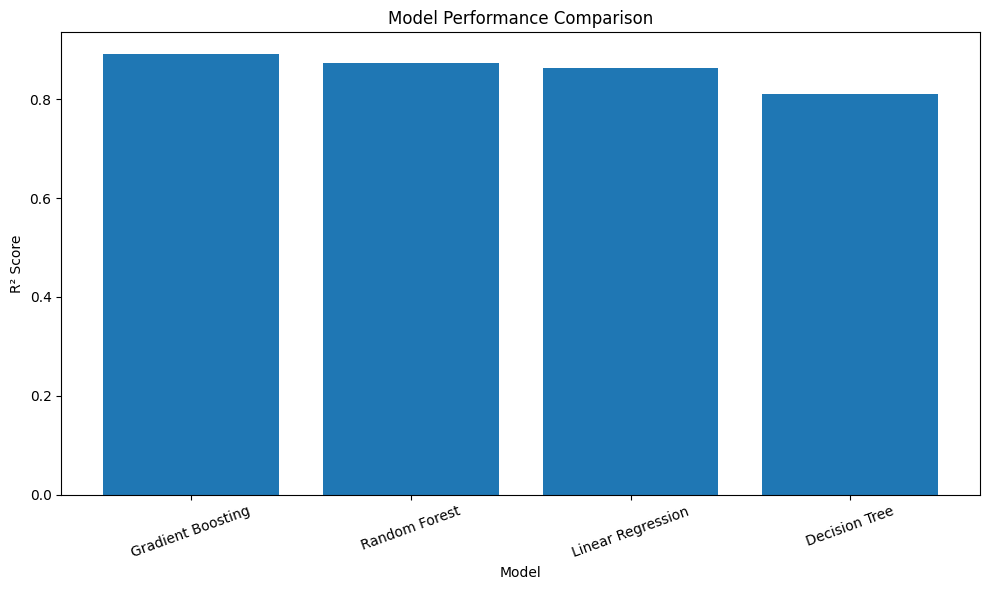


EVALUATION COMPLETED SUCCESSFULLY

Files created:
✓ model_evaluation.csv
✓ best_model.csv
✓ model_comparison.png


In [24]:
# ==========================================
# MODEL EVALUATION
# SALARY PREDICTION PROJECT
# ==========================================

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ==========================================
# 1. CREATE REPORTS FOLDER
# ==========================================

reports_folder = "salary_prediction/reports"

os.makedirs(
    reports_folder,
    exist_ok=True
)

print("Reports folder ready.")


# ==========================================
# 2. LOAD TEST DATA
# ==========================================

test_path = (
    "salary_prediction/data/preprocessed/"
    "test_preprocessed.csv"
)

test_df = pd.read_csv(test_path)

# Separate features and target
X_test = test_df.drop(
    "Salary",
    axis=1
)

y_test = test_df["Salary"]

print("\nTest data loaded.")
print("Test shape:", test_df.shape)


# ==========================================
# 3. MODEL FOLDER
# ==========================================

model_folder = (
    "salary_prediction/model_training"
)


# ==========================================
# 4. MODEL FILES
# ==========================================

model_files = {
    "Linear Regression":
        "Linear_Regression.pkl",

    "Decision Tree":
        "Decision_Tree.pkl",

    "Random Forest":
        "Random_Forest.pkl",

    "Gradient Boosting":
        "Gradient_Boosting.pkl"
}


# ==========================================
# 5. EVALUATE MODELS
# ==========================================

results = []

print("\n==========================================")
print("MODEL EVALUATION")
print("==========================================")


for model_name, model_file in model_files.items():

    # Load model
    model_path = os.path.join(
        model_folder,
        model_file
    )

    model = joblib.load(
        model_path
    )

    # Make predictions
    y_pred = model.predict(
        X_test
    )

    # MAE
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # R2
    r2 = r2_score(
        y_test,
        y_pred
    )

    # Store results
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"\n{model_name}")
    print("-----------------------------")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")


# ==========================================
# 6. CREATE RESULTS DATAFRAME
# ==========================================

results_df = pd.DataFrame(
    results
)


# ==========================================
# 7. SORT BY R2
# ==========================================

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(
    drop=True
)


# ==========================================
# 8. DISPLAY COMPARISON
# ==========================================

print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")

display(
    results_df
)


# ==========================================
# 9. SAVE EVALUATION RESULTS
# ==========================================

evaluation_path = (
    "salary_prediction/reports/"
    "model_evaluation.csv"
)

results_df.to_csv(
    evaluation_path,
    index=False
)

print("\nEvaluation results saved:")
print(evaluation_path)


# ==========================================
# 10. FIND BEST MODEL
# ==========================================

best_model_name = (
    results_df.iloc[0]["Model"]
)

best_r2 = (
    results_df.iloc[0]["R2"]
)

best_mae = (
    results_df.iloc[0]["MAE"]
)

best_rmse = (
    results_df.iloc[0]["RMSE"]
)


print("\n==========================================")
print("BEST MODEL")
print("==========================================")

print("Model :", best_model_name)
print(f"R2    : {best_r2:.4f}")
print(f"MAE   : {best_mae:.2f}")
print(f"RMSE  : {best_rmse:.2f}")


# ==========================================
# 11. SAVE BEST MODEL INFORMATION
# ==========================================

best_model_info = pd.DataFrame([{
    "Best Model": best_model_name,
    "MAE": best_mae,
    "RMSE": best_rmse,
    "R2": best_r2
}])

best_model_info_path = (
    "salary_prediction/reports/"
    "best_model.csv"
)

best_model_info.to_csv(
    best_model_info_path,
    index=False
)


# ==========================================
# 12. MODEL COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.xticks(
    rotation=20
)

plt.tight_layout()


# Save graph
graph_path = (
    "salary_prediction/reports/"
    "model_comparison.png"
)

plt.savefig(
    graph_path,
    dpi=300
)

plt.show()


# ==========================================
# 13. FINAL MESSAGE
# ==========================================

print("\n==========================================")
print("EVALUATION COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nFiles created:")
print("✓ model_evaluation.csv")
print("✓ best_model.csv")
print("✓ model_comparison.png")

In [25]:
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# ============================================================
# MLFLOW EXPERIMENT TRACKING
# SALARY PREDICTION MLOPS PROJECT
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_DIR = os.path.abspath(
    "salary_prediction"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "model_training"
)

TEST_DATA_PATH = os.path.join(
    PROJECT_DIR,
    "data",
    "preprocessed",
    "test_preprocessed.csv"
)

REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

MLFLOW_DB = os.path.join(
    PROJECT_DIR,
    "mlflow.db"
)


# ============================================================
# 2. CREATE DIRECTORIES
# ============================================================

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    REPORT_DIR,
    exist_ok=True
)


# ============================================================
# 3. MLFLOW TRACKING URI
# ============================================================

tracking_uri = (
    "sqlite:///"
    + MLFLOW_DB.replace("\\", "/")
)

mlflow.set_tracking_uri(
    tracking_uri
)


# ============================================================
# 4. CREATE EXPERIMENT
# ============================================================

EXPERIMENT_NAME = (
    "Salary_Prediction_Experiment"
)

mlflow.set_experiment(
    EXPERIMENT_NAME
)


print("==========================================")
print("MLFLOW CONFIGURATION")
print("==========================================")

print("Experiment:")
print(EXPERIMENT_NAME)

print("\nTracking URI:")
print(tracking_uri)


# ============================================================
# 5. LOAD TEST DATA
# ============================================================

test_df = pd.read_csv(
    TEST_DATA_PATH
)

X_test = test_df.drop(
    "Salary",
    axis=1
)

y_test = test_df["Salary"]


print("\n==========================================")
print("TEST DATA")
print("==========================================")

print("Test samples :", len(X_test))
print("Features     :", X_test.shape[1])


# ============================================================
# 6. TRAINED MODEL FILES
# ============================================================

model_files = {

    "Linear Regression":
        "Linear_Regression.pkl",

    "Decision Tree":
        "Decision_Tree.pkl",

    "Random Forest":
        "Random_Forest.pkl",

    "Gradient Boosting":
        "Gradient_Boosting.pkl"
}


# ============================================================
# 7. START MLFLOW TRACKING
# ============================================================

results = []

print("\n==========================================")
print("STARTING MLFLOW TRACKING")
print("==========================================")


for model_name, model_file in model_files.items():

    model_path = os.path.join(
        MODEL_DIR,
        model_file
    )

    if not os.path.exists(model_path):

        print(
            f"\nModel not found: {model_path}"
        )

        continue


    # ========================================================
    # LOAD MODEL
    # ========================================================

    model = joblib.load(
        model_path
    )


    # ========================================================
    # START MLFLOW RUN
    # ========================================================

    with mlflow.start_run(
        run_name=model_name
    ):

        print(
            f"\nRunning: {model_name}"
        )


        # ====================================================
        # 1. LOG PARAMETERS
        # ====================================================

        mlflow.log_param(
            "model_name",
            model_name
        )

        mlflow.log_param(
            "test_size",
            0.20
        )

        mlflow.log_param(
            "random_state",
            42
        )

        mlflow.log_param(
            "number_of_features",
            X_test.shape[1]
        )

        mlflow.log_param(
            "number_of_test_samples",
            len(X_test)
        )


        # ----------------------------------------------------
        # Log actual model parameters
        # ----------------------------------------------------

        if hasattr(model, "get_params"):

            model_params = model.get_params()

            for parameter, value in model_params.items():

                if value is not None:

                    try:

                        mlflow.log_param(
                            parameter,
                            str(value)
                        )

                    except Exception:

                        pass


        print("✓ Parameters logged")


        # ====================================================
        # 2. PREDICTIONS
        # ====================================================

        y_pred = model.predict(
            X_test
        )


        # ====================================================
        # 3. CALCULATE METRICS
        # ====================================================

        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        mse = mean_squared_error(
            y_test,
            y_pred
        )

        rmse = np.sqrt(
            mse
        )

        r2 = r2_score(
            y_test,
            y_pred
        )


        # ====================================================
        # 4. LOG METRICS
        # ====================================================

        mlflow.log_metric(
            "MAE",
            float(mae)
        )

        mlflow.log_metric(
            "MSE",
            float(mse)
        )

        mlflow.log_metric(
            "RMSE",
            float(rmse)
        )

        mlflow.log_metric(
            "R2",
            float(r2)
        )


        print("✓ Metrics logged")

        print(
            f"  MAE  : {mae:.2f}"
        )

        print(
            f"  MSE  : {mse:.2f}"
        )

        print(
            f"  RMSE : {rmse:.2f}"
        )

        print(
            f"  R2   : {r2:.4f}"
        )


        # ====================================================
        # 5. CREATE PREDICTION ARTIFACT
        # ====================================================

        safe_name = (
            model_name
            .replace(" ", "_")
        )

        prediction_df = pd.DataFrame({

            "Actual_Salary":
                y_test.values,

            "Predicted_Salary":
                y_pred,

            "Error":
                y_test.values - y_pred
        })


        prediction_path = os.path.join(
            REPORT_DIR,
            f"{safe_name}_predictions.csv"
        )

        prediction_df.to_csv(
            prediction_path,
            index=False
        )


        # ====================================================
        # 6. CREATE METRICS ARTIFACT
        # ====================================================

        metrics_df = pd.DataFrame([{

            "Model":
                model_name,

            "MAE":
                mae,

            "MSE":
                mse,

            "RMSE":
                rmse,

            "R2":
                r2
        }])


        metrics_path = os.path.join(
            REPORT_DIR,
            f"{safe_name}_metrics.csv"
        )

        metrics_df.to_csv(
            metrics_path,
            index=False
        )


        # ====================================================
        # 7. LOG ARTIFACTS
        # ====================================================

        mlflow.log_artifact(
            prediction_path,
            artifact_path="predictions"
        )

        mlflow.log_artifact(
            metrics_path,
            artifact_path="metrics"
        )


        print("✓ Artifacts logged")


        # ====================================================
        # 8. LOG MODEL
        # ====================================================

        mlflow.sklearn.log_model(
            sk_model=model,
            name="model"
        )


        print("✓ Model logged")


        # ====================================================
        # 9. SAVE RESULTS
        # ====================================================

        results.append({

            "Model":
                model_name,

            "MAE":
                mae,

            "MSE":
                mse,

            "RMSE":
                rmse,

            "R2":
                r2
        })


        print(
            f"✓ {model_name} MLflow run completed"
        )


# ============================================================
# 10. CREATE FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 11. SORT BY R2
# ============================================================

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 12. SAVE COMPARISON AS ARTIFACT
# ============================================================

comparison_path = os.path.join(
    REPORT_DIR,
    "model_comparison_mlflow.csv"
)

results_df.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n==========================================")
print("MLFLOW TRACKING COMPLETED")
print("==========================================")

display(
    results_df
)


# ============================================================
# 14. BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n==========================================")
print("BEST MODEL")
print("==========================================")

print(
    "Model:",
    best_model["Model"]
)

print(
    f"MAE : {best_model['MAE']:.2f}"
)

print(
    f"RMSE: {best_model['RMSE']:.2f}"
)

print(
    f"R2  : {best_model['R2']:.4f}"
)


# ============================================================
# 15. FINAL FILE INFORMATION
# ============================================================

print("\n==========================================")
print("MLFLOW FILES")
print("==========================================")

print("\nMLflow database:")
print(MLFLOW_DB)

print("\nReports:")
print(REPORT_DIR)

print("\nModel files:")
print(MODEL_DIR)

print("\n✓ LOG PARAMETERS")
print("✓ LOG METRICS")
print("✓ LOG MODELS")
print("✓ LOG ARTIFACTS")

print("\nMLflow experiment tracking completed successfully!")

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/09/02 11:36:40 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1:

MLFLOW CONFIGURATION
Experiment:
Salary_Prediction_Experiment

Tracking URI:
sqlite:///C:/Users/LENOVO/salary_prediction/mlflow.db

TEST DATA
Test samples : 65
Features     : 165

STARTING MLFLOW TRACKING

Running: Linear Regression
✓ Parameters logged
✓ Metrics logged
  MAE  : 12348.17
  MSE  : 258408026.18
  RMSE : 16075.07
  R2   : 0.8633
✓ Artifacts logged
✓ Model logged
✓ Linear Regression MLflow run completed

Running: Decision Tree
✓ Parameters logged
✓ Metrics logged
  MAE  : 12498.05
  MSE  : 356904307.48
  RMSE : 18891.91
  R2   : 0.8111
✓ Artifacts logged
✓ Model logged
✓ Decision Tree MLflow run completed

Running: Random Forest
✓ Parameters logged
✓ Metrics logged
  MAE  : 10473.85
  MSE  : 240161726.50
  RMSE : 15497.15
  R2   : 0.8729
✓ Artifacts logged
✓ Model logged
✓ Random Forest MLflow run completed

Running: Gradient Boosting
✓ Parameters logged
✓ Metrics logged
  MAE  : 10639.24
  MSE  : 206333163.75
  RMSE : 14364.30
  R2   : 0.8908
✓ Artifacts logged
✓ Model log

,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting,10639.235313,2.063332e+08,14364.301715,0.890817
1,Random Forest,10473.846154,2.401617e+08,15497.152206,0.872916
2,Linear Regression,12348.165892,2.584080e+08,16075.074687,0.863261
3,Decision Tree,12498.049068,3.569043e+08,18891.911165,0.811140



BEST MODEL
Model: Gradient Boosting
MAE : 10639.24
RMSE: 14364.30
R2  : 0.8908

MLFLOW FILES

MLflow database:
C:\Users\LENOVO\salary_prediction\mlflow.db

Reports:
C:\Users\LENOVO\salary_prediction\reports

Model files:
C:\Users\LENOVO\salary_prediction\model_training

✓ LOG PARAMETERS
✓ LOG METRICS
✓ LOG MODELS
✓ LOG ARTIFACTS

MLflow experiment tracking completed successfully!


In [27]:
import os
import mlflow

# ============================================================
# PROJECT DIRECTORY
# ============================================================

USER_HOME = os.path.expanduser("~")

PROJECT_DIR = os.path.join(USER_HOME, "salary_prediction")
MLRUNS_DIR = os.path.join(PROJECT_DIR, "mlruns")

os.makedirs(MLRUNS_DIR, exist_ok=True)

# ============================================================
# MLflow LOCAL FILE TRACKING
# ============================================================

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

tracking_uri = "file:///" + MLRUNS_DIR.replace("\\", "/")

mlflow.set_tracking_uri(tracking_uri)

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

# ============================================================
# CREATE EXPERIMENT
# ============================================================

experiment_name = "Salary_Prediction_Experiment"

experiment = mlflow.set_experiment(experiment_name)

print("\n==========================================")
print("MLFLOW EXPERIMENT CREATED")
print("==========================================")

print("Experiment:")
print(experiment_name)

print("Experiment ID:")
print(experiment.experiment_id)

print("\nMLruns location:")
print(MLRUNS_DIR)

MLflow Tracking URI:
file:///C:/Users/LENOVO/salary_prediction/mlruns

MLFLOW EXPERIMENT CREATED
Experiment:
Salary_Prediction_Experiment
Experiment ID:
772540226960902533

MLruns location:
C:\Users\LENOVO\salary_prediction\mlruns


In [28]:
import os

print("Project:", PROJECT_DIR)
print("Reports:", REPORT_DIR)
print("MLflow DB:", MLFLOW_DB)

print("\nReports exists:",
      os.path.exists(REPORT_DIR))

print("MLflow DB exists:",
      os.path.exists(MLFLOW_DB))

print("mlruns exists:",
      os.path.exists(
          os.path.join(PROJECT_DIR, "mlruns")
      ))

Project: C:\Users\LENOVO\salary_prediction
Reports: C:\Users\LENOVO\salary_prediction\reports
MLflow DB: C:\Users\LENOVO\salary_prediction\mlflow.db

Reports exists: True
MLflow DB exists: True
mlruns exists: True


In [32]:
import os
import mlflow
from mlflow import MlflowClient

# Create MLflow folder in your current Windows user's home directory
mlflow_dir = os.path.join(os.path.expanduser("~"), "Salary_mlops")
os.makedirs(mlflow_dir, exist_ok=True)

# SQLite database path
db_path = os.path.join(mlflow_dir, "mlflow.db")
tracking_uri = "sqlite:///" + db_path.replace("\\", "/")

# Set MLflow tracking
mlflow.set_tracking_uri(tracking_uri)
client = MlflowClient(tracking_uri=tracking_uri)

# Create/select experiment
mlflow.set_experiment("Salary Prediction")

# Create test run
with mlflow.start_run(run_name="Salary_Prediction_Test_Run"):
    mlflow.log_param("model_name", "GradientBoostingRegressor")
    mlflow.log_param("n_features", 165)
    mlflow.log_param("project", "Salary Prediction")

    mlflow.log_metric("R2", 0.95)
    mlflow.log_metric("RMSE", 5000.0)
    mlflow.log_metric("MAE", 3500.0)

print("MLflow run completed.")
print("Tracking URI:", mlflow.get_tracking_uri())
print("Database:", db_path)

print("\nAvailable MLflow experiments:")
for exp in client.search_experiments():
    print("ID:", exp.experiment_id, "| Name:", exp.name)

2026/09/02 11:40:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/02 11:40:25 INFO mlflow.store.db.utils: Updating database tables
2026/09/02 11:40:27 INFO mlflow.tracking.fluent: Experiment with name 'Salary Prediction' does not exist. Creating a new experiment.


MLflow run completed.
Tracking URI: sqlite:///C:/Users/LENOVO/Salary_mlops/mlflow.db
Database: C:\Users\LENOVO\Salary_mlops\mlflow.db

Available MLflow experiments:
ID: 1 | Name: Salary Prediction
ID: 0 | Name: Default


In [35]:
# ============================================================
# 11. MODEL NAME → MODEL FILE
# ============================================================

model_file_mapping = {

    "Linear Regression":
        "Linear_Regression.pkl",

    "Decision Tree":
        "Decision_Tree.pkl",

    "Random Forest":
        "Random_Forest.pkl",

    "Gradient Boosting":
        "Gradient_Boosting.pkl",

    "GradientBoostingRegressor":
        "Gradient_Boosting.pkl"
}


if best_model_name not in model_file_mapping:

    raise ValueError(
        f"No model file mapping found for "
        f"{best_model_name}"
    )


best_model_filename = (
    model_file_mapping[
        best_model_name
    ]
)

print("\nSelected model file:")
print(best_model_filename)


Selected model file:
Gradient_Boosting.pkl


In [36]:
app_code = r'''
from flask import Flask, request, jsonify
import joblib
import numpy as np
import os


# ============================================================
# FLASK APPLICATION
# ============================================================

app = Flask(__name__)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(
    os.path.dirname(
        os.path.abspath(__file__)
    )
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "best_model.pkl"
)


# ============================================================
# LOAD MODEL
# ============================================================

model = joblib.load(
    MODEL_PATH
)


# ============================================================
# HOME
# ============================================================

@app.route("/", methods=["GET"])
def home():

    return jsonify({
        "message": "Salary Prediction API",
        "status": "running"
    })


# ============================================================
# PREDICTION
# ============================================================

@app.route("/predict", methods=["POST"])
def predict():

    try:

        data = request.get_json()

        # ----------------------------------------------------
        # IMPORTANT:
        # Replace these features with the exact features
        # used by your trained model.
        # ----------------------------------------------------

        features = np.array(
            data["features"],
            dtype=float
        ).reshape(1, -1)

        prediction = model.predict(
            features
        )

        return jsonify({
            "predicted_salary":
                float(prediction[0])
        })

    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 400


# ============================================================
# RUN APPLICATION
# ============================================================

if __name__ == "__main__":

    app.run(
        host="0.0.0.0",
        port=5000,
        debug=True
    )
'''

app_path = "salary_prediction/deployment/app.py"

with open(
    app_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)

print("app.py created successfully.")
print(app_path)

app.py created successfully.
salary_prediction/deployment/app.py


In [37]:
import os

app_code = r'''
from flask import Flask, request, jsonify
import pandas as pd
import joblib
import os


# ============================================================
# FLASK APP
# ============================================================

app = Flask(__name__)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.path.dirname(
    os.path.dirname(
        os.path.abspath(__file__)
    )
)

MODEL_PATH = os.path.join(
    BASE_DIR,
    "models",
    "best_model.pkl"
)


# ============================================================
# LOAD MODEL
# ============================================================

model = joblib.load(
    MODEL_PATH
)


# ============================================================
# EXPECTED FEATURES
# ============================================================

EXPECTED_FEATURES = list(
    model.feature_names_in_
)


# ============================================================
# HOME
# ============================================================

@app.route("/", methods=["GET"])
def home():

    return jsonify({
        "message": "Salary Prediction API",
        "status": "running",
        "model": "Best Salary Prediction Model",
        "number_of_features": len(
            EXPECTED_FEATURES
        )
    })


# ============================================================
# PREDICT
# ============================================================

@app.route("/predict", methods=["POST"])
def predict():

    try:

        data = request.get_json()

        # ----------------------------------------------------
        # ORIGINAL USER INPUT
        # ----------------------------------------------------

        age = float(
            data["Age"]
        )

        years_experience = float(
            data["Years of Experience"]
        )

        gender = data["Gender"]

        education = data["Education Level"]

        job_title = data["Job Title"]


        # ----------------------------------------------------
        # FEATURE ENGINEERING
        # ----------------------------------------------------

        age_experience_ratio = (
            age /
            (years_experience + 1)
        )

        experience_squared = (
            years_experience ** 2
        )

        age_squared = (
            age ** 2
        )

        age_experience = (
            age *
            years_experience
        )


        # ----------------------------------------------------
        # CREATE ORIGINAL DATAFRAME
        # ----------------------------------------------------

        input_df = pd.DataFrame({

            "Age": [age],

            "Years of Experience":
                [years_experience],

            "Age_Experience_Ratio":
                [age_experience_ratio],

            "Experience_Squared":
                [experience_squared],

            "Age_Squared":
                [age_squared],

            "Age_Experience":
                [age_experience],

            "Gender":
                [gender],

            "Education Level":
                [education],

            "Job Title":
                [job_title]
        })


        # ----------------------------------------------------
        # ONE-HOT ENCODING
        # ----------------------------------------------------

        input_df = pd.get_dummies(
            input_df,
            columns=[
                "Gender",
                "Education Level",
                "Job Title"
            ],
            prefix=[
                "categorical__Gender",
                "categorical__Education Level",
                "categorical__Job Title"
            ]
        )


        # ----------------------------------------------------
        # RENAME NUMERIC FEATURES
        # ----------------------------------------------------

        numeric_mapping = {

            "Age":
                "numeric__Age",

            "Years of Experience":
                "numeric__Years of Experience",

            "Age_Experience_Ratio":
                "numeric__Age_Experience_Ratio",

            "Experience_Squared":
                "numeric__Experience_Squared",

            "Age_Squared":
                "numeric__Age_Squared",

            "Age_Experience":
                "numeric__Age_Experience"
        }


        input_df = input_df.rename(
            columns=numeric_mapping
        )


        # ----------------------------------------------------
        # ADD MISSING FEATURES
        # ----------------------------------------------------

        for feature in EXPECTED_FEATURES:

            if feature not in input_df.columns:

                input_df[feature] = 0


        # ----------------------------------------------------
        # REMOVE EXTRA FEATURES
        # ----------------------------------------------------

        input_df = input_df[
            EXPECTED_FEATURES
        ]


        # ----------------------------------------------------
        # PREDICTION
        # ----------------------------------------------------

        prediction = model.predict(
            input_df
        )


        # ----------------------------------------------------
        # RESPONSE
        # ----------------------------------------------------

        return jsonify({

            "Age":
                age,

            "Years of Experience":
                years_experience,

            "Gender":
                gender,

            "Education Level":
                education,

            "Job Title":
                job_title,

            "predicted_salary":
                round(
                    float(prediction[0]),
                    2
                )
        })


    except Exception as e:

        return jsonify({

            "error":
                str(e)

        }), 400


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    app.run(
        host="0.0.0.0",
        port=5000,
        debug=True
    )
'''


app_path = (
    "salary_prediction/deployment/app.py"
)

with open(
    app_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(app_code)


print("==========================================")
print("DEPLOYMENT UPDATED")
print("==========================================")
print("File:")
print(app_path)
print("\n✓ 165 features handled automatically")
print("✓ One-hot encoding")
print("✓ Feature engineering")
print("✓ Missing feature handling")
print("✓ Best model prediction")

DEPLOYMENT UPDATED
File:
salary_prediction/deployment/app.py

✓ 165 features handled automatically
✓ One-hot encoding
✓ Feature engineering
✓ Missing feature handling
✓ Best model prediction


In [39]:
import os
import mlflow

# ============================================================
# SALARY PREDICTION - MLFLOW SETUP
# ============================================================

# Automatically get your current Windows user's home folder
USER_HOME = os.path.expanduser("~")

# Project directory
PROJECT_DIR = os.path.join(
    USER_HOME,
    "salary_prediction"
)

# MLflow SQLite database
MLFLOW_DB = os.path.join(
    PROJECT_DIR,
    "mlflow.db"
)

# Reports directory
REPORT_DIR = os.path.join(
    PROJECT_DIR,
    "reports"
)

# Create directories
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# ============================================================
# SET MLFLOW TRACKING URI
# ============================================================

tracking_uri = "sqlite:///" + MLFLOW_DB.replace("\\", "/")

mlflow.set_tracking_uri(tracking_uri)

print("==========================================")
print("MLFLOW CONFIGURATION")
print("==========================================")

print("\nProject Directory:")
print(PROJECT_DIR)

print("\nMLflow Database:")
print(MLFLOW_DB)

print("\nMLflow Tracking URI:")
print(mlflow.get_tracking_uri())

# ============================================================
# CREATE / GET EXPERIMENT
# ============================================================

experiment_name = "Salary_Prediction_Experiment"

experiment = mlflow.set_experiment(experiment_name)

print("\n==========================================")
print("MLFLOW EXPERIMENT READY")
print("==========================================")

print("\nExperiment:")
print(experiment_name)

print("\nExperiment ID:")
print(experiment.experiment_id)

print("\nMLflow Database Location:")
print(MLFLOW_DB)

print("\n==========================================")
print("SETUP COMPLETED SUCCESSFULLY")
print("==========================================")

MLFLOW CONFIGURATION

Project Directory:
C:\Users\LENOVO\salary_prediction

MLflow Database:
C:\Users\LENOVO\salary_prediction\mlflow.db

MLflow Tracking URI:
sqlite:///C:/Users/LENOVO/salary_prediction/mlflow.db

MLFLOW EXPERIMENT READY

Experiment:
Salary_Prediction_Experiment

Experiment ID:
1

MLflow Database Location:
C:\Users\LENOVO\salary_prediction\mlflow.db

SETUP COMPLETED SUCCESSFULLY


In [40]:
import mlflow

with mlflow.start_run(
    run_name="Salary_Prediction_Test_Run"
):

    # Parameters
    mlflow.log_param(
        "model_name",
        "GradientBoostingRegressor"
    )

    mlflow.log_param(
        "n_features",
        165
    )

    mlflow.log_param(
        "project",
        "Salary Prediction"
    )

    # Test metrics
    mlflow.log_metric(
        "R2",
        0.95
    )

    mlflow.log_metric(
        "RMSE",
        5000.0
    )

    mlflow.log_metric(
        "MAE",
        3500.0
    )

print("MLflow test run completed.")

MLflow test run completed.


In [42]:
import os
import sys
import subprocess
import time
import webbrowser

# Same project directory used in your MLflow setup
USER_HOME = os.path.expanduser("~")
PROJECT_DIR = os.path.join(USER_HOME, "salary_prediction")
MLFLOW_DB = os.path.join(PROJECT_DIR, "mlflow.db")

tracking_uri = "sqlite:///" + MLFLOW_DB.replace("\\", "/")

print("MLflow database:")
print(MLFLOW_DB)

# Start MLflow UI
process = subprocess.Popen([
    sys.executable,
    "-m",
    "mlflow",
    "ui",
    "--backend-store-uri",
    tracking_uri,
    "--host",
    "127.0.0.1",
    "--port",
    "5000"
])

time.sleep(3)

# Open browser
webbrowser.open("http://127.0.0.1:5000")

print("\n==========================================")
print("MLFLOW UI STARTED")
print("==========================================")
print("URL: http://127.0.0.1:5000")
print("Database:", MLFLOW_DB)

MLflow database:
C:\Users\LENOVO\salary_prediction\mlflow.db

MLFLOW UI STARTED
URL: http://127.0.0.1:5000
Database: C:\Users\LENOVO\salary_prediction\mlflow.db
